# Support Vector Regression (SVR): California Housing Value Prediction

## Objective
Build and evaluate a Support Vector Regression model to predict `median_house_value` from California housing attributes.

This notebook includes:
- Data validation and exploratory data analysis (EDA)
- Leakage-safe preprocessing for numeric and categorical features
- A baseline SVR and cross-validation
- Target scaling using `TransformedTargetRegressor`
- Hyperparameter tuning with `GridSearchCV`
- Final test-set evaluation, baseline comparison, and residual analysis
- Saving the fitted preprocessing/model pipeline

**Important:** RBF SVR can be computationally expensive on larger datasets. Hyperparameter tuning is therefore performed on a reproducible sample of the training split by default. The held-out test split is kept separate from model selection.

## 1. Imports and configuration

In [21]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

RANDOM_STATE = 42

# To keep RBF-SVR tuning practical on the California housing dataset.
# Increase this after confirming that runtime and memory are acceptable.
MAX_TUNING_ROWS = 3000
CV_SPLITS = 3

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
warnings.filterwarnings("default")

## 2. Load the dataset

Expected project structure:

```text
project-root/
├── data/
│   └── housePriceDataset.csv
├── notebooks/
│   └── svr.ipynb
└── models/
```

The path lookup supports running this notebook from the project root or from the `notebooks/` directory.

In [22]:
candidate_paths = [
    Path("data/housePriceDataset.csv"),
    Path("../data/housePriceDataset.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    expected = "\n".join(f"- {path}" for path in candidate_paths)
    raise FileNotFoundError(
        "Could not find housePriceDataset.csv. Check the dataset location. "
        f"Expected one of:\n{expected}"
    )

PROJECT_ROOT = DATA_PATH.resolve().parent.parent
df = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH.resolve()}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
display(df.head())

Loaded: C:\ML\SVM\data\housePriceDataset.csv
Rows: 20,640 | Columns: 10


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Inspect and validate the data

In [23]:
display(df.info())
display(df.describe(include="all").T)

print("Duplicate rows:", df.duplicated().sum())

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
})
display(missing_summary.sort_values("missing_percent", ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Duplicate rows: 0


,missing_count,missing_percent
total_bedrooms,207,1.0
longitude,0,0.0
latitude,0,0.0
housing_median_age,0,0.0
total_rooms,0,0.0
population,0,0.0
households,0,0.0
median_income,0,0.0
median_house_value,0,0.0
ocean_proximity,0,0.0


In [24]:
TARGET = "median_house_value"

FEATURES = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "ocean_proximity",
]

required_columns = FEATURES + [TARGET]
missing_columns = sorted(set(required_columns) - set(df.columns))

if missing_columns:
    raise ValueError(
        "The dataset is missing required columns: "
        f"{missing_columns}. Check the CSV schema."
    )

# Target values cannot be imputed for supervised training.
df = df.dropna(subset=[TARGET]).copy()

X = df[FEATURES].copy()
y = pd.to_numeric(df[TARGET], errors="raise").astype(float)

numerical_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
]
categorical_features = ["ocean_proximity"]

print("Feature columns:", FEATURES)
print(f"Target: {TARGET}")
print(f"Valid rows after removing missing targets: {len(df):,}")
print("Target summary:")
display(y.describe().to_frame(name=TARGET))

Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
Target: median_house_value
Valid rows after removing missing targets: 20,640
Target summary:


,median_house_value
count,20640.000000
mean,206855.816909
std,115395.615874
min,14999.000000
25%,119600.000000
50%,179700.000000
75%,264725.000000
max,500001.000000


## 4. Exploratory data analysis

The plots below help inspect the target distribution, missing data, and relationships between selected features and house value. Correlation is descriptive and does not establish causation.

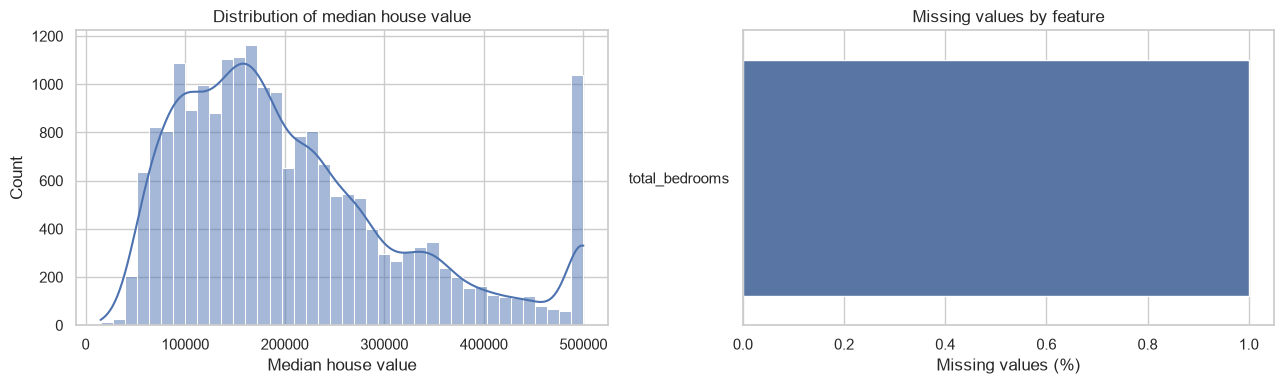

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df, x=TARGET, bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribution of median house value")
axes[0].set_xlabel("Median house value")

missing_plot = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_percent")
if not missing_plot.empty:
    sns.barplot(
        x=missing_plot["missing_percent"],
        y=missing_plot.index,
        ax=axes[1],
    )
    axes[1].set_title("Missing values by feature")
    axes[1].set_xlabel("Missing values (%)")
    axes[1].set_ylabel("")
else:
    axes[1].text(0.5, 0.5, "No missing values", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

c:\ML\SVM\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


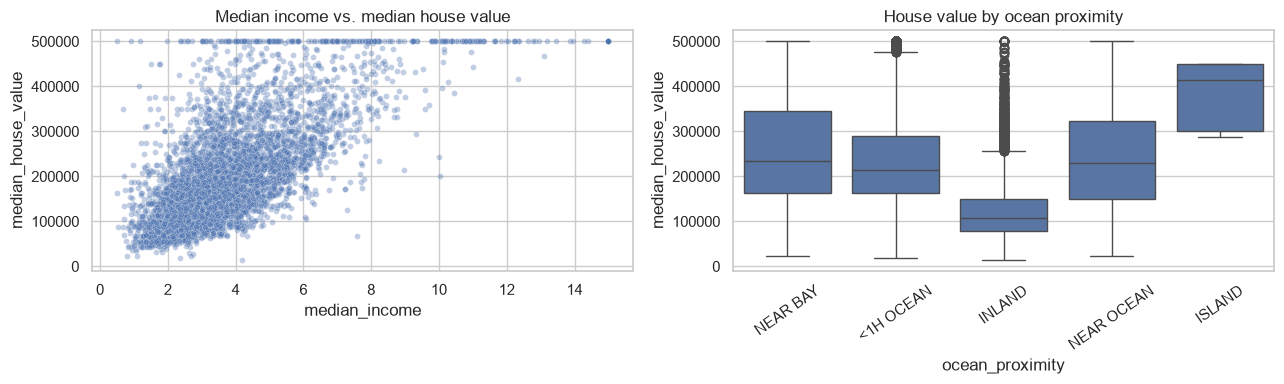

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=RANDOM_STATE),
    x="median_income",
    y=TARGET,
    alpha=0.35,
    s=18,
    ax=axes[0],
)
axes[0].set_title("Median income vs. median house value")

sns.boxplot(data=df, x="ocean_proximity", y=TARGET, ax=axes[1])
axes[1].set_title("House value by ocean proximity")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

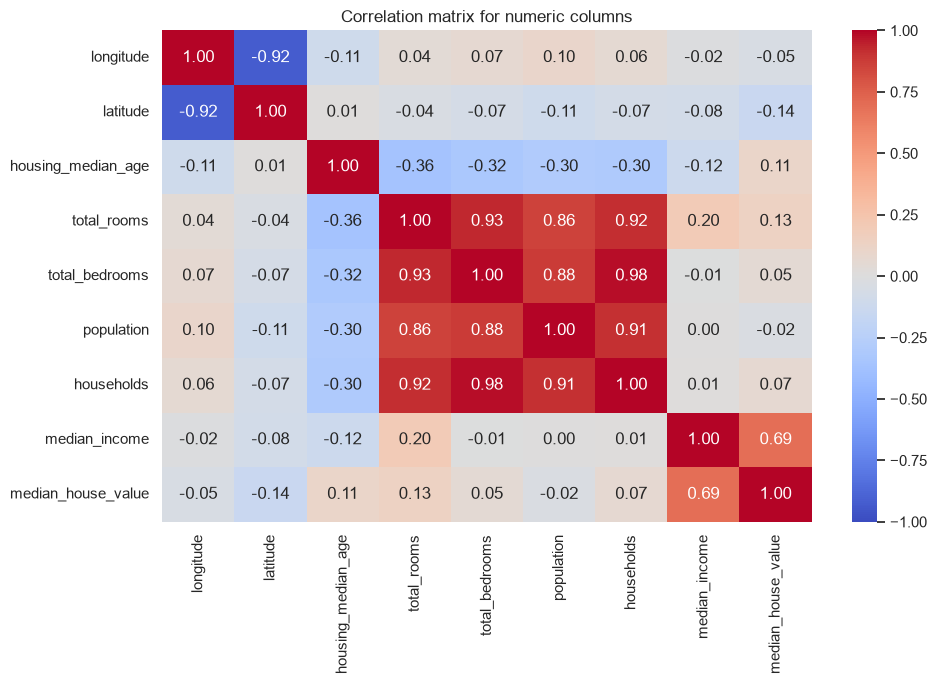

,correlation_with_target
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


In [27]:
numeric_for_corr = df.select_dtypes(include="number")

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_for_corr.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation matrix for numeric columns")
plt.tight_layout()
plt.show()

display(
    numeric_for_corr.corr()[TARGET]
    .sort_values(ascending=False)
    .rename("correlation_with_target")
    .to_frame()
)

## 5. Train-test split

The test set is held out for final evaluation. It is not used for preprocessing fit, cross-validation, or hyperparameter selection.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 16,512
Test rows: 4,128


## 6. Preprocessing pipeline

- Numerical features: median imputation, then standardization.
- Categorical feature: most-frequent imputation, then one-hot encoding.
- The preprocessing is fitted within each training fold through the pipeline, preventing validation/test data from influencing imputation, scaling, or encoding.

SVR is sensitive to feature scales, so standardizing numerical inputs is important.

In [29]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features),
])

svr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("svr", SVR(kernel="rbf")),
])

svr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

## 7. Address target scale with TransformedTargetRegressor

`median_house_value` is measured in large dollar-like values, while SVR's default `epsilon=0.1` is tiny relative to that target scale. This can produce a poorly configured regression problem.

`TransformedTargetRegressor` standardizes the target during fitting and automatically converts predictions back to the original target scale. Because it is part of the estimator, the target scaler is fitted only on each training fold during cross-validation.

In [30]:
model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler(),
)

model

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...svr', SVR())])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",StandardScaler()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indica

## 8. Create a reproducible tuning sample

RBF SVR can require substantial time and memory as the number of training examples grows. We sample from the training split for cross-validation and hyperparameter search. The sample is selected only from `X_train` / `y_train`; the test set remains untouched.

Increase `MAX_TUNING_ROWS` if you have enough time and memory. For large-scale production datasets, consider models that scale better than kernel SVR.

In [31]:
tuning_size = min(MAX_TUNING_ROWS, len(X_train))

X_tune = X_train.sample(
    n=tuning_size,
    random_state=RANDOM_STATE,
)
y_tune = y_train.loc[X_tune.index]

print(f"Rows used for SVR tuning: {len(X_tune):,} of {len(X_train):,} available training rows")
print(f"Rows reserved for final test evaluation: {len(X_test):,}")

Rows used for SVR tuning: 3,000 of 16,512 available training rows
Rows reserved for final test evaluation: 4,128


## 9. Baseline SVR cross-validation

This evaluates the initial RBF SVR with default SVR hyperparameters and target scaling. The split strategy is shuffled K-fold cross-validation, appropriate for this regression task.

In [32]:
cv = KFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

baseline_cv_scores = cross_val_score(
    model,
    X_tune,
    y_tune,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
)

print("Baseline SVR CV R² scores:", np.round(baseline_cv_scores, 4))
print(f"Mean CV R²: {baseline_cv_scores.mean():.4f}")
print(f"Standard deviation: {baseline_cv_scores.std():.4f}")

Baseline SVR CV R² scores: [0.7309 0.7412 0.6836]
Mean CV R²: 0.7186
Standard deviation: 0.0250


## 10. Hyperparameter tuning with GridSearchCV

Tune `C`, `epsilon`, and `gamma`. Since the target is standardized inside `TransformedTargetRegressor`, candidate `epsilon` values are interpreted in standardized-target units.

The grid below is deliberately modest to keep the exercise feasible. The CV objective is \(R^2\), which is invariant to linear target scaling.

In [33]:
param_grid = {
    "regressor__svr__C": [1, 10, 100],
    "regressor__svr__epsilon": [0.05, 0.2],
    "regressor__svr__gamma": ["scale", 0.1],
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

grid_search.fit(X_tune, y_tune)
best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print(f"\nBest mean CV R²: {grid_search.best_score_:.4f}")

Best parameters:
{'regressor__svr__C': 10, 'regressor__svr__epsilon': 0.2, 'regressor__svr__gamma': 0.1}

Best mean CV R²: 0.7341


In [34]:
cv_results = (
    pd.DataFrame(grid_search.cv_results_)
    .sort_values("rank_test_score")
    [[
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "params",
    ]]
    .head(10)
    .reset_index(drop=True)
)
display(cv_results)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
0,1,0.734056,0.026194,0.793603,"{'regressor__svr__C': 10, 'regressor__svr__eps..."
1,2,0.733045,0.026285,0.805770,"{'regressor__svr__C': 10, 'regressor__svr__eps..."
2,3,0.732338,0.026236,0.804357,"{'regressor__svr__C': 10, 'regressor__svr__eps..."
3,4,0.732280,0.026301,0.791943,"{'regressor__svr__C': 10, 'regressor__svr__eps..."
4,5,0.719075,0.024958,0.754543,"{'regressor__svr__C': 1, 'regressor__svr__epsi..."
5,6,0.717658,0.024857,0.755226,"{'regressor__svr__C': 1, 'regressor__svr__epsi..."
6,7,0.715402,0.023888,0.744886,"{'regressor__svr__C': 1, 'regressor__svr__epsi..."
7,8,0.712932,0.024249,0.744952,"{'regressor__svr__C': 1, 'regressor__svr__epsi..."
8,9,0.706401,0.022647,0.835754,"{'regressor__svr__C': 100, 'regressor__svr__ep..."
9,10,0.701346,0.027148,0.834036,"{'regressor__svr__C': 100, 'regressor__svr__ep..."


## 11. Final test-set evaluation

The selected model is evaluated once on the held-out test set. Metrics are reported on the original target scale after inverse transformation by `TransformedTargetRegressor`.

In [35]:
y_pred = best_model.predict(X_test)

def regression_metrics(y_true, y_hat):
    mse = mean_squared_error(y_true, y_hat)
    return {
        "MAE": mean_absolute_error(y_true, y_hat),
        "Median absolute error": median_absolute_error(y_true, y_hat),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y_true, y_hat),
    }

test_metrics = pd.DataFrame.from_dict(
    regression_metrics(y_test, y_pred),
    orient="index",
    columns=["Score"],
)

display(test_metrics.style.format("{:,.4f}"))

,Score
MAE,"39,481.4225"
Median absolute error,"26,172.4107"
MSE,"3,459,343,907.8854"
RMSE,"58,816.1875"
R²,0.7360


## 12. Compare with a simple baseline

A useful regression model should outperform a simple baseline. The `DummyRegressor` below predicts the mean target value from the same tuning sample. The dummy model and the SVR are evaluated on exactly the same test rows.

In [36]:
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_tune, y_tune)

dummy_pred = dummy_model.predict(X_test)

comparison_metrics = pd.DataFrame({
    "DummyRegressor (mean)": regression_metrics(y_test, dummy_pred),
    "Tuned SVR": regression_metrics(y_test, y_pred),
}).T

display(comparison_metrics.style.format("{:,.4f}"))

,MAE,Median absolute error,MSE,RMSE,R²
DummyRegressor (mean),"91,249.4342","76,450.0000","13,127,109,387.6313","114,573.5981",-0.0018
Tuned SVR,"39,481.4225","26,172.4107","3,459,343,907.8854","58,816.1875",0.7360


## 13. Visualize predictions and residuals

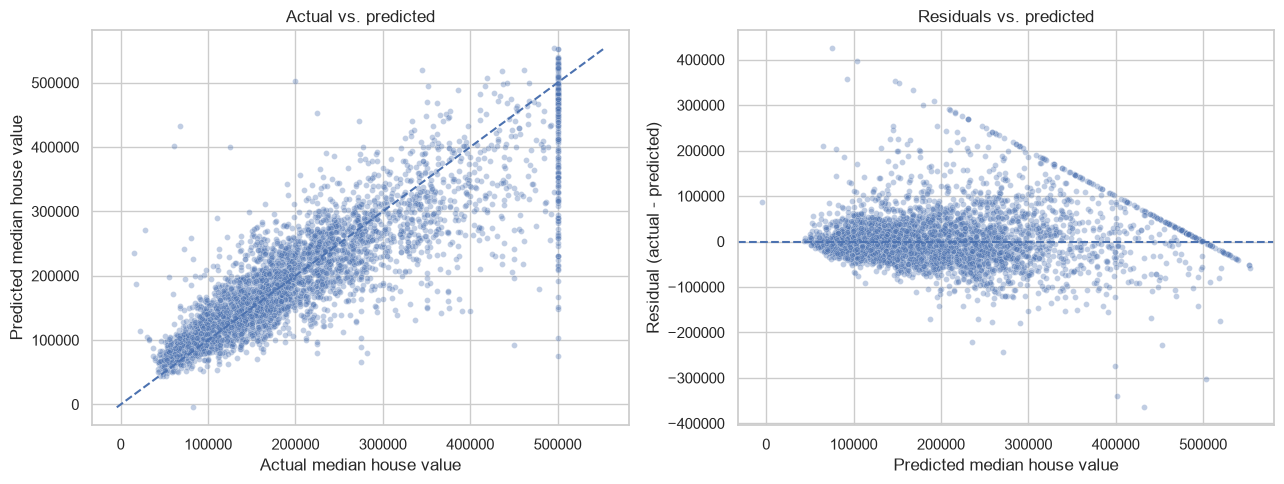

In [37]:
plot_sample = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": np.asarray(y_pred),
    "Residual": np.asarray(y_test) - np.asarray(y_pred),
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=plot_sample.sample(min(4000, len(plot_sample)), random_state=RANDOM_STATE),
    x="Actual",
    y="Predicted",
    alpha=0.35,
    s=18,
    ax=axes[0],
)
low = min(plot_sample["Actual"].min(), plot_sample["Predicted"].min())
high = max(plot_sample["Actual"].max(), plot_sample["Predicted"].max())
axes[0].plot([low, high], [low, high], linestyle="--")
axes[0].set_title("Actual vs. predicted")
axes[0].set_xlabel("Actual median house value")
axes[0].set_ylabel("Predicted median house value")

sns.scatterplot(
    data=plot_sample.sample(min(4000, len(plot_sample)), random_state=RANDOM_STATE),
    x="Predicted",
    y="Residual",
    alpha=0.35,
    s=18,
    ax=axes[1],
)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals vs. predicted")
axes[1].set_xlabel("Predicted median house value")
axes[1].set_ylabel("Residual (actual - predicted)")

plt.tight_layout()
plt.show()

In [38]:
display(
    plot_sample.head(20).style.format({
        "Actual": "{:,.0f}",
        "Predicted": "{:,.0f}",
        "Residual": "{:,.0f}",
    })
)

,Actual,Predicted,Residual
0,"47,700","67,809","-20,109"
1,"45,800","98,542","-52,742"
2,"500,001","373,440","126,561"
3,"218,600","236,489","-17,889"
4,"278,000","273,761","4,239"
5,"158,700","120,437","38,263"
6,"198,200","311,326","-113,126"
7,"157,500","195,114","-37,614"
8,"340,000","224,098","115,902"
9,"446,600","474,338","-27,738"


## 14. Save the fitted pipeline

The complete estimator stores preprocessing, SVR, and the fitted target transformer. Predictions are made with raw feature values in the same column format as `X`.

In [39]:
model_dir = PROJECT_ROOT / "models"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "svr_california_housing.joblib"
joblib.dump(best_model, model_path)

print(f"Saved model to: {model_path.resolve()}")

Saved model to: C:\ML\SVM\models\svr_california_housing.joblib


In [40]:
# Example: reload and predict for a few passengers/records from the test features.
loaded_model = joblib.load(model_path)
sample_X = X_test.head(5)
sample_predictions = loaded_model.predict(sample_X)

display(
    sample_X.assign(Predicted_median_house_value=sample_predictions)
)

,longitude,latitude,housing_median_age,total_bedrooms,population,households,median_income,ocean_proximity,Predicted_median_house_value
20046,-119.01,36.06,25.0,NaN,1392.0,359.0,1.6812,INLAND,67808.900797
3024,-119.46,35.14,30.0,NaN,1565.0,584.0,2.5313,INLAND,98542.400318
15663,-122.44,37.80,52.0,NaN,1310.0,963.0,3.4801,NEAR BAY,373440.490988
20484,-118.72,34.28,17.0,NaN,1705.0,495.0,5.7376,<1H OCEAN,236488.979576
9814,-121.93,36.62,34.0,NaN,1063.0,428.0,3.7250,NEAR OCEAN,273761.395088


## 15. Conclusions and limitations

- **Data limitation:** California housing benchmark data has known limitations; median house values in this dataset are capped at an upper value. This can limit how well any model predicts expensive districts.
- **Runtime limitation:** tuning uses a random training subset because RBF SVR scales poorly as the number of rows grows. The measured model performance should be interpreted in light of that choice.

A negative test \(R^2\) means the fitted model is worse than predicting the test-set mean under the \(R^2\) definition. Investigate the baseline comparison and residual plots rather than hiding poor results.